# Student dropout dataset

### importing packages

In [2]:


import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

### importing dataset

In [15]:
students_dropout=pd.read_csv('student_dropout.csv',delimiter=';')

In [16]:
students_dropout.head(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,39,1,9991,0,19,133.1,1,37,37,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,9500,1,1,142.0,1,19,38,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,1,18,4,9254,1,1,119.0,1,37,37,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,1,1,3,9238,1,1,137.0,62,1,1,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,1,1,1,9238,1,1,138.0,1,1,19,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


In [17]:
students_dropout.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance\t', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd

In [18]:
students_dropout.dtypes

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance\t                        int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

### selctinmg features and target

In [19]:
X=students_dropout.drop(columns=['Target'])
y=students_dropout['Target']

### scaling the features and encoding the target variable

In [10]:
scaler=StandardScaler()
encoder=LabelEncoder()


In [21]:
y_encoded = encoder.fit_transform(y)

# Print the class mapping to understand the encoding
print("Class mapping:")
for i, class_name in enumerate(encoder.classes_):
    print(f"{class_name}: {i}")
num_classes = len(encoder.classes_)
print(f"\nTotal number of classes: {num_classes}")

Class mapping:
Dropout: 0
Enrolled: 1
Graduate: 2

Total number of classes: 3


In [22]:
X_scaled=scaler.fit_transform(X).astype(np.float32)

### train test split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [24]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train
)

In [25]:
print(f"Training Features (X_train):   {X_train.shape}")
print(f"Validation Features (X_val): {X_val.shape}")
print(f"Test Features (X_test):      {X_test.shape}")
print(f"\nTraining Labels (y_train):     {y_train.shape}")
print(f"Validation Labels (y_val):   {y_val.shape}")
print(f"Test Labels (y_test):        {y_test.shape}")

Training Features (X_train):   (2831, 36)
Validation Features (X_val): (708, 36)
Test Features (X_test):      (885, 36)

Training Labels (y_train):     (2831,)
Validation Labels (y_val):   (708,)
Test Labels (y_test):        (885,)


### building pytorch sets

In [56]:

train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).long())
val_ds   = TensorDataset(torch.from_numpy(X_val),   torch.from_numpy(y_val).long())
test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test).long())



### creating dataloader

In [57]:
batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)


### model

In [58]:
input_features = X_train.shape[1] 
num_classes = 3 # Dropout, Enrolled, Graduate

model = nn.Sequential(
    nn.Linear(input_features, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, num_classes)
)

### loss function and optimizer

In [59]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### training loop

In [60]:
epochs = 12
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print("Starting model training...")

for epoch in range(1, epochs + 1):
    # Training phase
    model.train()
    running_loss, running_corrects = 0.0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.double() / len(train_loader.dataset)
    history['train_loss'].append(epoch_loss)
    history['train_acc'].append(epoch_acc.item())

    # Validation phase
    model.eval()
    val_loss, val_corrects = 0.0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_corrects += torch.sum(preds == labels.data)

    val_epoch_loss = val_loss / len(val_loader.dataset)
    val_epoch_acc = val_corrects.double() / len(val_loader.dataset)
    history['val_loss'].append(val_epoch_loss)
    history['val_acc'].append(val_epoch_acc.item())

    # Print progress
    if epoch % 2 == 0 or epoch == 1:
        print(f"Epoch {epoch:02d}/{epochs} | "
              f"Train Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f} | "
              f"Val Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.4f}")

print("\nTraining finished.")

Starting model training...
Epoch 01/12 | Train Loss: 0.9045 Acc: 0.5775 | Val Loss: 0.7235 Acc: 0.7359
Epoch 02/12 | Train Loss: 0.6723 Acc: 0.7262 | Val Loss: 0.6301 Acc: 0.7486
Epoch 04/12 | Train Loss: 0.5830 Acc: 0.7630 | Val Loss: 0.5919 Acc: 0.7571
Epoch 06/12 | Train Loss: 0.5550 Acc: 0.7796 | Val Loss: 0.5823 Acc: 0.7641
Epoch 08/12 | Train Loss: 0.5343 Acc: 0.7845 | Val Loss: 0.5812 Acc: 0.7684
Epoch 10/12 | Train Loss: 0.5184 Acc: 0.7895 | Val Loss: 0.5784 Acc: 0.7712
Epoch 12/12 | Train Loss: 0.5033 Acc: 0.8011 | Val Loss: 0.5806 Acc: 0.7684

Training finished.


### test set eval

In [61]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# --- 2. Print Classification Report ---
print("--- Classification Report on Test Set ---")
# Use the label_encoder to get the original class names
class_names = encoder.classes_
print(classification_report(all_labels, all_preds, target_names=class_names))

--- Classification Report on Test Set ---
              precision    recall  f1-score   support

     Dropout       0.79      0.75      0.77       284
    Enrolled       0.49      0.36      0.42       159
    Graduate       0.80      0.90      0.85       442

    accuracy                           0.76       885
   macro avg       0.69      0.67      0.68       885
weighted avg       0.74      0.76      0.75       885



### confusion matrix

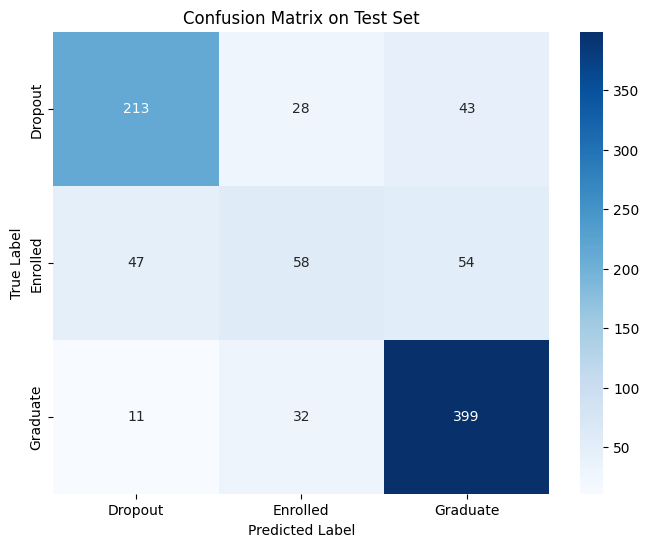

In [62]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix on Test Set')
plt.show()

### plotiing learning curves

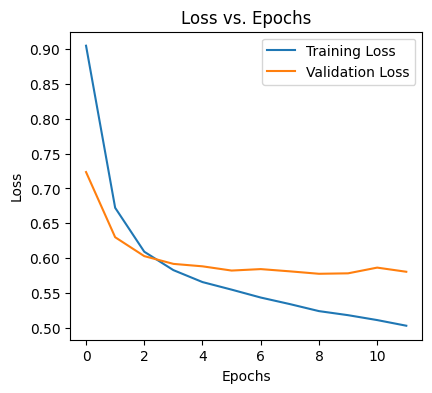

In [63]:
# Plot Loss
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Loss vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

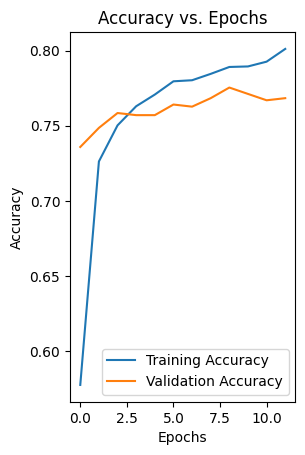

In [64]:
# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Training Accuracy')
plt.plot(history['val_acc'], label='Validation Accuracy')
plt.title('Accuracy vs. Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

this indicates overfitting 